In [33]:
from qiskit import QuantumCircuit
from qiskit.compiler import transpile
from matplotlib import pyplot as plt
import numpy as np
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.quantum_info import Operator

from qiskit.quantum_info import SparsePauliOp

from qiskit.quantum_info import Statevector

In [34]:
from pmns import PMNS_matrix_4x4
from hamiltonians import U1_omega_Omega, theta_ij, J_ij
from hamiltonians import nunu_interaction_p, nunu_interaction, nunu_interaction_s
from helpers import get_target_state, swap_correction_order_bp, get_interaction_pair_index, count_2q

from backend import get_sampler, get_estimator
from transpile import produce_transpile_args

import sys

sys.path.append('../utils/')

from JobResult import JobResult
from DecoherenceRenormalizer import DecoherenceRenormalizer as DR
from Collector import Collector

from RunSaver import RunSaver

In [35]:
rs = RunSaver("8nu_estimator_Ideal")

savepath = 'results'
run_name = '8nu_estimator_Ideal'

SAVEFLAG = True

transpile_config_path = "config/default.json"

# backend settings
# aer, sherbrooke, fez, or ibm

shots = 8192

provider = 'aer'
estimator, backend, config = get_estimator(provider)
estimator.options.default_shots = shots
N = 8

# trotter settings
# set in natural units here
# conversion to mu^-1 happens later automatically
# dt = 5
T_max = 5.6
steps = 5

# run settings

transpile_args = produce_transpile_args(config=config, path=transpile_config_path)
print(f"Transpile args: {transpile_args}")


rs.save_multiple([
    ('savepath', savepath),
    ('run_name', run_name),
    ('provider', provider),
    ('transpile_config_path', transpile_config_path),
    ('shots', shots),
    ('steps', steps),
    ('T_max', T_max),
])

Using Noiseless Aer
Transpile args: {'optimization_level': 3, 'basis_gates': None, 'initial_layout': None, 'approximation_degree': 1}


In [36]:
#### Defining PMNS matrix and parameters for the Hamiltonian ####
theta_12 = np.radians(33.67)
theta_13 = np.radians(8.58)
theta_23 = np.radians(42.3)
delta_CP = np.radians(232)

U_PMNS_4x4 = PMNS_matrix_4x4(theta_12, theta_13, theta_23, delta_CP)
assert np.allclose(U_PMNS_4x4.conj().T @ U_PMNS_4x4, np.eye(4)), "PMNS matrix is not unitary"

dm21 = 7.41e-5
dm31 = 2.505e-3
E = 1.0

delta_m21 = dm21
delta_m31 = dm31
delta_m32 = delta_m31 - delta_m21
#mu=dm31*N/(2*E) #* 1e-8
mu = dm31 * N / (2 * E)
#omega = np.sqrt(delta_m21**2 + ((delta_m31 + delta_m32)**2) / 3) / (4 * E)
omega=dm21 / (2 * E)  
Omega= dm31 / (2 * E)
#B3 = delta_m21 / np.sqrt(delta_m21**2 + ((delta_m31 + delta_m32)**2) / 3)
#B8 = (delta_m31 + delta_m32) / (np.sqrt(3) * np.sqrt(delta_m21**2 + ((delta_m31 + delta_m32)**2) / 3))
B3=0.025483
B8=0.999567
B = np.zeros(8)
B[2] = B3
B[7] = B8

T_max = T_max / mu
times = np.linspace(0, T_max, steps)

rs.save_multiple([
    ('dm21', dm21),
    ('dm31', dm31),
    ('E', E),
    ('mu', mu),
    ('omega', omega),
    ('Omega', Omega),
    ('B3', B3),
    ('B8', B8),
    ('B', B)
])

In [37]:
def apply_nunu_interaction(qc, pair_indices, order, base_pattern, dt, interact_func = nunu_interaction, post_fix_func = None):
    """
    interact_func: function for the interaction, for example, nunu_interaction or nunu_interaction_p
    post_fix_func: function to update the order and base_pattern after interaction, given by (order, base_pattern, i, j) -> (new_order, new_base_pattern)
    """
    for i, j in pair_indices:
        q = [2*i, 2*i+1, 2*j, 2*j+1]
        alpha_ij = J_ij(order[i], order[j], E, mu, N) * dt

        interact_func(qc, q, alpha_ij)
        order, base_pattern = post_fix_func(order, base_pattern, i, j) if post_fix_func else (order, base_pattern)
        
    return order, base_pattern


In [38]:
# initialization for run


def init_order_and_base_pattern():
    # generate initial pattern
    base_pattern = []
    for i in range(N):
        if i % 4 == 1:
            base_pattern.append('M')  # nu_mu
        elif i % 4 == 3:
            base_pattern.append('T')  # nu_tau
        else:
            base_pattern.append('E')  # nu_e

    # order map
    order = [i for i in range(N)]

    return order, base_pattern

# interaction sequence
method = "bubble"

pair_indices = get_interaction_pair_index(N, method = method)

rs.save("pair_indices", method)

collector = Collector(run_name)

rs.save("Type", "swap")


In [ ]:
identity_observable = 'I' * (2 * N)

observables = []

def whereisnu(i, order):
    # We do the subtraction here because qiskit convention is reverse order
    pos = len(order) - 1 - order.index(i)
    print(f"whereisnu: {i} is at position {pos} in order {order}")
    print(f"whereisnu: {i} is at position {pos} in order {order}, which corresponds to qubits {2 * pos} and {2 * pos + 1}")
    return 2 * pos, 2 * pos + 1

def projector_on_qubit(loc, state):
    a, b = loc

    if state == '00':
        return SparsePauliOp.from_list([
            (identity_observable, 0.25),
            (identity_observable[:a] + 'Z' + identity_observable[a+1:], 0.25),
            (identity_observable[:b] + 'Z' + identity_observable[b+1:], 0.25),
            (identity_observable[:a] + 'ZZ' + identity_observable[b+1:], 0.25),
        ])
    elif state == '10':
        return SparsePauliOp.from_list([
            (identity_observable, 0.25),
            (identity_observable[:a] + 'Z' + identity_observable[a+1:], 0.25),
            (identity_observable[:b] + 'Z' + identity_observable[b+1:], -0.25),
            (identity_observable[:a] + 'ZZ' + identity_observable[b+1:], -0.25),
        ])
    elif state == '01':
        return SparsePauliOp.from_list([
            (identity_observable, 0.25),
            (identity_observable[:a] + 'Z' + identity_observable[a+1:], -0.25),
            (identity_observable[:b] + 'Z' + identity_observable[b+1:], +0.25),
            (identity_observable[:a] + 'ZZ' + identity_observable[b+1:], -0.25),
        ])
    elif state == '11':
        raise ValueError("Currently not supported to project on '11' state")

things_to_observe = {}

# observe everything
for i in range(N):
    things_to_observe[i] = ['00', '01', '10']

rs.save("things_to_observe", things_to_observe)

for t in times:
    collector.add("t", t * mu)

    dt = t
    print("############################################")
    print("Time step:", t)

    order, base_pattern = init_order_and_base_pattern()
    print("Initial order:", order)
    qc = QuantumCircuit(2 * N, 2 * N)

    # Initial state: alternate nu_e, nu_mu, nu_e, nu_tau pattern
    for i in range(N):
        if i % 4 == 1:
            qc.x(2*i + 1)  # nu_mu = |01⟩
        elif i % 4 == 3:
            qc.x(2*i)      # nu_tau = |10⟩

    # Apply U†_PMNS
    Udag = Operator(U_PMNS_4x4.conj().T)
    for i in range(N):
        qc.unitary(Udag, [2*i, 2*i+1], label="U†_PMNS")

    # interaction
    for i in range(N):
        qc.append(U1_omega_Omega(dt, omega, Omega), [2*i, 2*i+1])

    order, base_pattern = apply_nunu_interaction(qc, pair_indices, order, base_pattern, dt,
                                                    interact_func=nunu_interaction_p,
                                                    post_fix_func=swap_correction_order_bp)
    
    # state = Statevector.from_instruction(qc)

    # print("State after interaction:", np.abs(state).round(2))
                                                    
    # order, base_pattern = apply_nunu_interaction(qc, pair_indices, order, base_pattern, dt,
    #                                              interact_func=nunu_interaction,
    #                                              post_fix_func=None)

    # Apply U_PMNS
    # U = Operator(U_PMNS_4x4)
    for i in range(N):
        qc.unitary(Udag, [2*i, 2*i+1], label="U†_PMNS").inverse()

    # Here we construct the observables
    observables = []

    print(order)
    print(base_pattern)

    for key in things_to_observe.keys():
        for state in things_to_observe[key]:
            print(f"Observing state {state} for nu_{key}")
            loc = whereisnu(key, order)
            obs = projector_on_qubit(loc, state)
            observables.append(obs)

    print("Observables:", observables)

    transpile_args = produce_transpile_args(config=config, path=transpile_config_path)

    tqc = transpile(qc, backend, **transpile_args)

    job = JobResult(get_sampler(provider)[0], verbose=True)
    job.run(tqc, run_options={'shots': shots})
    print("Sampler result:", job.get_counts())

    print("Transpiled circuit has {0} two-qubit gates.".format(count_2q(tqc)))

    job = JobResult(estimator, verbose=True)

    job.run((tqc, observables), run_options={})

    evs = job.get_estimator_result()

    collector.add("evs", evs)

    print(evs)

if SAVEFLAG:
    collector.save(path=savepath)

rs.log("logs")

############################################
Time step: 0.0
Initial order: [0, 1, 2, 3, 4, 5, 6, 7]
[7, 6, 5, 4, 3, 2, 1, 0]
['T', 'E', 'M', 'E', 'T', 'E', 'M', 'E']
Observing state 00 for nu_0
Observing state 01 for nu_0
Observing state 10 for nu_0
Observing state 00 for nu_1
Observing state 01 for nu_1
Observing state 10 for nu_1
Observing state 00 for nu_2
Observing state 01 for nu_2
Observing state 10 for nu_2
Observing state 00 for nu_3
Observing state 01 for nu_3
Observing state 10 for nu_3
Observing state 00 for nu_4
Observing state 01 for nu_4
Observing state 10 for nu_4
Observing state 00 for nu_5
Observing state 01 for nu_5
Observing state 10 for nu_5
Observing state 00 for nu_6
Observing state 01 for nu_6
Observing state 10 for nu_6
Observing state 00 for nu_7
Observing state 01 for nu_7
Observing state 10 for nu_7
Observables: [SparsePauliOp(['IIIIIIIIIIIIIIII', 'IIIIIIIIIIIIIIZI', 'IIIIIIIIIIIIIIIZ', 'IIIIIIIIIIIIIIZZ'],
              coeffs=[0.25+0.j, 0.25+0.j, 0.25+0.j, 

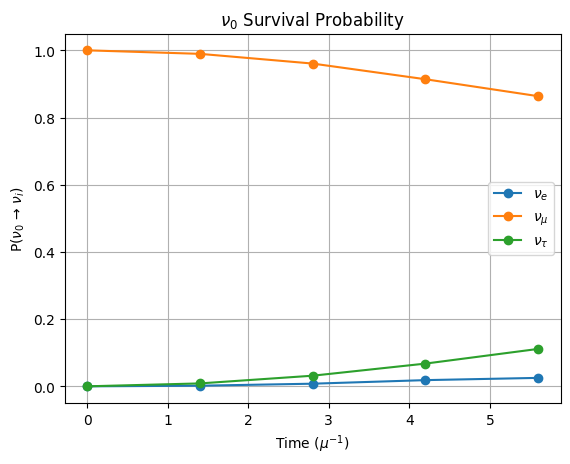

In [40]:
# Plot
plt.plot(collector.get("t"), np.asarray(collector.get("evs"))[:, 0], marker='o', label=r'$\nu_e$')
plt.plot(collector.get("t"), np.asarray(collector.get("evs"))[:, 1], marker='o', label=r'$\nu_\mu$')
plt.plot(collector.get("t"), np.asarray(collector.get("evs"))[:, 2], marker='o', label=r'$\nu_\tau$')

plt.xlabel(r"Time ($\mu^{-1}$)")
plt.ylabel(r"P($\nu_0$ → $\nu_i$)")
plt.title(r"$\nu_0$ Survival Probability")
plt.grid(True)

plt.legend()
# plt.savefig(f"{run_name}_survprob.png")